# Multi-PDF Long-Context Evaluation

Test 3 approaches semantic, keyword, long-context where the entire 3 manuala are fed into the context 

**Models:** GPT-5.4 mini, GPT-5.4 nano  
**QA:** Combined Mill + HAAS Lathe + UR5e Cobot question sets

In [1]:
import sys, json, re
from pathlib import Path
from datetime import date

import pandas as pd
import fitz
import tiktoken
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from langchain_community.document_loaders import PyMuPDFLoader

sys.path.insert(0, str(Path("..").resolve())) # because we are pulling these in a jupyter notebook, we need to add the parent directory to the path to access the system module

from system.rag import (
    LLM,
    Approaches,
    RAGExperimentRunner,
    CSVProcessor,
    LangfairMetricsCalculator,
    LangfairRunner,
    ApproachRetrievers,
)
from system.preprocess import PDFPreprocessor
from system.evaluation import (
    JudgeBatchConfig,
    JudgeBatchBuilder,
    BatchResultsConfig,
    BatchResultsExporter,
    JudgeMergeConfig,
    JudgeResultsMerger,
    CSVColumnMergeConfig,
    CSVColumnMerger,
)
from system.utils import EnvironmentConfig, read_text


c:\Users\singhr7\Documents\safety_rag_evaluation_ryan\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


# Run Directory Setup

All artifacts for this run live under one directory.

In [2]:
RUN_ID = f"{date.today().isoformat()}_multi_pdf_eval"
RUN_DIR = Path(f"../data/results/runs/multi_pdf/{RUN_ID}")

for sub in ["rag", "raw", "parsed", "merged", "meta"]:
    (RUN_DIR / sub).mkdir(parents=True, exist_ok=True)
print(RUN_ID)
print(f"Run directory: {RUN_DIR.resolve()}")


2026-04-17_multi_pdf_eval
Run directory: C:\Users\singhr7\Documents\safety_rag_evaluation_ryan\data\results\runs\multi_pdf\2026-04-17_multi_pdf_eval


# Crop PDFs

Crop all 3 manuals to remove headers/footers and reduce token count.

In [3]:
PDF_DIR = Path("../data/input/input_pdfs")
CROP_DIR = Path("../data/input/cropped_pdfs")
CROP_DIR.mkdir(parents=True, exist_ok=True)

TARGETS = {
    "Mill (Bridgeport)": {
        "path": PDF_DIR / "Bridgeport Series 1 Milling manual with schematics.pdf",
        "crop_top": 0.04, "crop_bottom": 0.075, "crop_left": 0.0, "crop_right": 0.0,
    },
    "Lathe (HAAS TL-1)": {
        "path": PDF_DIR / "TL1_lathe operator's-manual.pdf",
        "crop_percent": 0.075,
    },
    "UR5e Cobot": {
        "path": PDF_DIR / "UR5e_Universal_Robots User Manual.pdf",
        "crop_percent": 0.075,
    },
}

CROPPED = {}
for label, cfg in TARGETS.items():
    out = CROP_DIR / f"cropped_{cfg['path'].name}"
    PDFPreprocessor.crop_pdf(
        cfg["path"], out,
        crop_percent=cfg.get("crop_percent", 0.075),
        crop_top=cfg.get("crop_top"),
        crop_bottom=cfg.get("crop_bottom"),
        crop_left=cfg.get("crop_left"),
        crop_right=cfg.get("crop_right"),
    )
    CROPPED[label] = out
    print(f"Cropped {label} -> {out.name}")

Cropped Mill (Bridgeport) -> cropped_Bridgeport Series 1 Milling manual with schematics.pdf
Cropped Lathe (HAAS TL-1) -> cropped_TL1_lathe operator's-manual.pdf
Cropped UR5e Cobot -> cropped_UR5e_Universal_Robots User Manual.pdf


# Load Cropped Text & Token Counts

In [4]:
def load_pdf_as_text(path) -> str:
    pages = PyMuPDFLoader(str(path)).load()
    return "\n\n".join(p.page_content for p in pages).strip()

enc = tiktoken.get_encoding("cl100k_base")
cropped_texts = {}
total_tokens = 0

for label in TARGETS:
    text = load_pdf_as_text(CROPPED[label])
    cropped_texts[label] = text
    n_tokens = len(enc.encode(text))
    total_tokens += n_tokens
    print(f"{label:25s}  {len(text):>10,} chars   {n_tokens:>8,} tokens")

print(f"\n{'COMBINED':25s}  {'':>10s}        {total_tokens:>8,} tokens")

Mill (Bridgeport)             121,502 chars     45,319 tokens
Lathe (HAAS TL-1)             557,235 chars    154,558 tokens
UR5e Cobot                    253,244 chars     60,754 tokens

COMBINED                                      260,631 tokens


In [5]:

print(cropped_texts["UR5e Cobot"][4500:5000])

print("================================\n")
print(cropped_texts["Lathe (HAAS TL-1)"][900:5000])


ccessing Robot Data
204
16. Disposal and Environment
206
17. Declarations and Certificates (original EN)
208
18. Declarations and Certificates
210
19. Safety Functions Table
212
19.1. Table 1a
219
19.2. Table 2
220
20. Certifications
224
21. Certificates
226



1. Liability and Intended Use
1.1. Limitation of Liability
Description
Any information provided in this manual must not be construed as a warranty, by UR,
that the industrial robot will not cause injury or damage, even if the industrial r

lity 
damages resulting from the use of the information contained in this publication

s product uses Java Technology from Oracle Corporation and we request that you acknowledge that 
acle owns the Java Trademark and all Java related Trademarks and agree to comply with the 
demark guidelines at www.oracle.com/us/legal/third-party-trademarks/index.html. 
y further distribution of the Java programs (beyond this appliance/machine) is subject to a legally 
ding End User License Agreement with Orac

# Combine QA Sets

Merge Mill, HAAS Lathe, and UR5e Cobot QA into a single CSV with a `machine` column.

In [6]:
QA_SOURCES = {
    "Mill (Bridgeport)": Path("../data/QA/MILL/Mill Feedback Accepted.csv"),
    "Lathe (HAAS TL-1)": Path("../data/QA/HAAS/Final HAAS Lathe QA.csv"),
    "UR5e Cobot":        Path("../data/QA/COBOT/Final_COBOT_QA.csv"),
}

frames = []
for machine, path in QA_SOURCES.items():
    tmp = pd.read_csv(path)[["question", "gold_answer"]].copy()
    tmp.insert(0, "machine", machine)
    frames.append(tmp)

combined_qa = pd.concat(frames, ignore_index=True)

COMBINED_QA = RUN_DIR / "meta" / "combined_multi_pdf_qa.csv"
combined_qa.to_csv(COMBINED_QA, index=False)

print(f"Total questions: {len(combined_qa)}")
print(combined_qa["machine"].value_counts())

Total questions: 162
machine
UR5e Cobot           60
Mill (Bridgeport)    51
Lathe (HAAS TL-1)    51
Name: count, dtype: int64


In [7]:
## not null in any columns
combined_qa.isnull().sum()


machine        0
question       0
gold_answer    0
dtype: int64

In [8]:
combined_qa.sample(5)

,machine,question,gold_answer
33,Mill (Bridgeport),What are the steps for the pre-operational saf...,Ensure no slip/trip hazards are present in wor...
161,UR5e Cobot,The safety settings in the configuration wont ...,If the safety settings are not letting you cha...
39,Mill (Bridgeport),How do I lock the spindle on the bridgeport mill?,Use the spindle brake. It is located on the l...
152,UR5e Cobot,What is a pinch hazard in robot operation?,A pinch hazard occurs when body parts can be c...
123,UR5e Cobot,Is it ok to use any type of packaging to move ...,"No, not using the original packaging when tran..."


# Configure & Run Experiment

In [9]:
env_config = EnvironmentConfig()
rets = ApproachRetrievers(env_config)

# Long-context gets ALL 3 manuals
rets.set_long_context_texts(cropped_texts)

runner = RAGExperimentRunner(
    retrievers=rets,
    num_replicates=1,
    approaches=Approaches.OPENAI_SEMANTIC | Approaches.OPENAI_KEYWORD | Approaches.LONG_CONTEXT,
    models=LLM.GPT_5_4_MINI_2026_03_17 | LLM.GPT_5_4_NANO_2026_03_17,
    max_tokens_list=[5000],
    efforts=["low"],
    topk_list=[3],
    ans_instr_A=read_text("../data/prompts/ans_instr_A.txt"),
    fewshot_A=read_text("../data/prompts/fewshot_A.txt"),
    max_concurrent=5,
    max_chars_per_content=500_000,
    include_hits_text=False,
)
print(runner)

RAGExperimentRunner Configuration
  Approaches       : ['openai_keyword', 'openai_semantic', 'long_context']
  Models           : ['gpt-5.4-mini-2026-03-17', 'gpt-5.4-nano-2026-03-17']
  Max tokens       : [5000]
  Efforts          : ['low']
  Top-k            : [3]
  Answer instr IDs : ['A']
  Few-shot IDs     : ['A']
  Replicates       : 1
  Max concurrent   : 5
  Max chars/content: 500,000
  Include hits text: False
  Min words subsplit: 3000


In [10]:
# test_combined_qa = combined_qa.sample(n=2)
# test_qa_path = RUN_DIR / "meta" / "test_combined_qa.csv"
# test_combined_qa.to_csv(test_qa_path, index=False)

# test_combined_qa.shape

In [11]:
combined_qa.shape

(162, 3)

In [12]:
combined_qa = pd.read_csv(COMBINED_QA)

In [13]:
combined_qa.shape

(162, 3)

In [16]:
RAG_OUTPUT = RUN_DIR / "rag" / "MULTI_PDF_OUTPUT_merge_all.csv"

if not RAG_OUTPUT.exists():
    print("Running RAG experiment...")

Running RAG experiment...


In [17]:
await runner.run(COMBINED_QA, RAG_OUTPUT)

RAGExperimentRunner Configuration
  Approaches       : ['openai_keyword', 'openai_semantic', 'long_context']
  Models           : ['gpt-5.4-mini-2026-03-17', 'gpt-5.4-nano-2026-03-17']
  Max tokens       : [5000]
  Efforts          : ['low']
  Top-k            : [3]
  Answer instr IDs : ['A']
  Few-shot IDs     : ['A']
  Replicates       : 1
  Max concurrent   : 5
  Max chars/content: 500,000
  Include hits text: False
  Min words subsplit: 3000
----------------------------------------
  Questions        : 162
  Total permutations: 972
Completed 5 runs for approach=openai_keyword, model=gpt-5.4-mini-2026-03-17
Completed 10 runs for approach=openai_keyword, model=gpt-5.4-mini-2026-03-17
Completed 15 runs for approach=openai_keyword, model=gpt-5.4-mini-2026-03-17
Completed 20 runs for approach=openai_keyword, model=gpt-5.4-mini-2026-03-17
Completed 25 runs for approach=openai_keyword, model=gpt-5.4-mini-2026-03-17
Completed 30 runs for approach=openai_keyword, model=gpt-5.4-mini-2026-03-

[{'permutation_id': 'eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2lkIjoiQSIsImFwcHJvYWNoIjoibG9uZ19jb250ZXh0IiwiZWZmb3J0IjoibG93IiwiZmV3X3Nob3RfaWQiOiJBIiwibWF4X3Rva2VucyI6NTAwMCwibW9kZWwiOiJncHQtNS40LW5hbm8tMjAyNi0wMy0xNyIsInJlYXNvbmluZ19lZmZvcnQiOiJsb3ciLCJ0b3BfayI6M30sInJ1bl91dWlkIjoiNzVkNWFiOWUtMDFlNS00NzE4LTk1ZjMtNmExMWI4MDQ2YzBjIn2Vx65mLvSN7A',
  'time_started': '2026-04-17 11:04:27 EDT',
  'time_ended': '2026-04-17 11:04:30 EDT',
  'total_elapsed_time': '2.33 Seconds',
  'min_words_for_subsplit': 3000,
  'approach': 'long_context',
  'model': 'gpt-5.4-nano-2026-03-17',
  'max_tokens': 5000,
  'reasoning_effort': 'low',
  'top_k': 3,
  'answer_instructions_id': 'A',
  'few_shot_id': 'A',
  'replicate': 1,
  'question': 'Who should perform the risk assessment for the arm?',
  'gold_answer': 'Risk assessment is the responsibility of the integrator. The user of the robot arm can be the integrator.',
  'generated_answer': 'The risk assessment for the UR robot application (including 

In [18]:
df = pd.read_csv(RAG_OUTPUT)
print(f"Rows: {len(df)}")
print(f"Approaches: {sorted(df['approach'].unique())}")
print(f"Models: {sorted(df['model'].unique()) if 'model' in df.columns else sorted(df['meta_model'].unique())}")
df.tail(3)

Rows: 972
Approaches: ['long_context', 'openai_keyword', 'openai_semantic']
Models: ['gpt-5.4-mini-2026-03-17', 'gpt-5.4-nano-2026-03-17']


,permutation_id,time_started,time_ended,total_elapsed_time,min_words_for_subsplit,approach,model,max_tokens,reasoning_effort,top_k,...,generated_answer,retrieved_files,meta_resp_id,meta_model,meta_status,meta_created,meta_input_tokens,meta_output_tokens,meta_total_tokens,meta_reason
969,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 11:04:23 EDT,2026-04-17 11:04:25 EDT,1.97 Seconds,3000,long_context,gpt-5.4-nano-2026-03-17,5000,low,3,...,The cybersecurity risk assessment should be co...,Mill (Bridgeport);Lathe (HAAS TL-1);UR5e Cobot,resp_05df65e35a909b3a0069e24bf7af648192b48c6d2...,gpt-5.4-nano-2026-03-17,completed,1.776438e+09,247742,30,247772,NaN
970,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 11:04:27 EDT,2026-04-17 11:04:30 EDT,2.33 Seconds,3000,long_context,gpt-5.4-nano-2026-03-17,5000,low,3,...,The risk assessment for the UR robot applicati...,Mill (Bridgeport);Lathe (HAAS TL-1);UR5e Cobot,resp_0f3cba7bf201e13a0069e24bfc115081978e9539b...,gpt-5.4-nano-2026-03-17,completed,1.776438e+09,247744,103,247847,NaN
971,eyJtZXRhZGF0YSI6eyJhbnN3ZXJfaW5zdHJ1Y3Rpb25zX2...,2026-04-17 11:04:27 EDT,2026-04-17 11:04:31 EDT,3.93 Seconds,3000,long_context,gpt-5.4-nano-2026-03-17,5000,low,3,...,"In the UR PolyScope safety configuration, cert...",Mill (Bridgeport);Lathe (HAAS TL-1);UR5e Cobot,resp_07cd3807ef9661a80069e24bfc1070819c94c71be...,gpt-5.4-nano-2026-03-17,completed,1.776438e+09,247750,253,248003,NaN


In [19]:
df.shape

(972, 25)

In [20]:
df.columns

Index(['permutation_id', 'time_started', 'time_ended', 'total_elapsed_time',
       'min_words_for_subsplit', 'approach', 'model', 'max_tokens',
       'reasoning_effort', 'top_k', 'answer_instructions_id', 'few_shot_id',
       'replicate', 'question', 'gold_answer', 'generated_answer',
       'retrieved_files', 'meta_resp_id', 'meta_model', 'meta_status',
       'meta_created', 'meta_input_tokens', 'meta_output_tokens',
       'meta_total_tokens', 'meta_reason'],
      dtype='object')

# Compute Similarity Metrics

In [21]:
metrics_runner = LangfairRunner(
    calculator=LangfairMetricsCalculator(),
    processor=CSVProcessor(),
    max_concurrent=500,
)
await metrics_runner.run(q_a_csv=RAG_OUTPUT, out_csv=None)

Total rows to process: 972
Processed 500/972 rows...
Saved results → C:\Users\singhr7\Documents\safety_rag_evaluation_ryan\data\results\runs\multi_pdf\2026-04-17_multi_pdf_eval\rag\MULTI_PDF_OUTPUT_merge_all_with_metrics.csv


WindowsPath('../data/results/runs/multi_pdf/2026-04-17_multi_pdf_eval/rag/MULTI_PDF_OUTPUT_merge_all_with_metrics.csv')

# Judge Batch (Helpfulness & Correctness)

## Sanity Checks 

In [24]:
# 1. Input CSV exists and has rows
assert RAG_OUTPUT.exists(), f"RAG output not found: {RAG_OUTPUT}"
df_check = pd.read_csv(RAG_OUTPUT)
assert len(df_check) > 0, "RAG output is empty"
print(f" RAG output: {len(df_check)} rows")



 RAG output: 972 rows


In [26]:
# 2. Required columns present
required_cols = {"question", "gold_answer", "generated_answer"}
missing = required_cols - set(df_check.columns)
assert not missing, f"Missing columns: {missing}"
print(f"Required columns present: {required_cols}")



Required columns present: {'generated_answer', 'gold_answer', 'question'}


In [28]:
# 3. No nulls in key columns
nulls = df_check[list(required_cols)].isnull().sum()
assert nulls.sum() == 0, f"Nulls found:\n{nulls[nulls > 0]}"
print(f"✓ No nulls in key columns")



✓ No nulls in key columns


## Judge Builder

In [30]:
judge_config = JudgeBatchConfig(
    csv_path=RAG_OUTPUT,
    output_jsonl=RUN_DIR / "raw" / "MULTI_PDF_BATCH.jsonl",
    judge_model="gpt-5",
    completion_window="24h",
    submit_to_openai=True,
    env_file=None,
)
builder = JudgeBatchBuilder(judge_config)
result = builder.run()
print(f"Prepared {result['num_requests']} requests (submitted={result['submitted']})")

batch_69e24f1bcc108190a5525c9e9ae2e541
Prepared 1944 requests (submitted=True)


In [36]:
batch_id = {"MULTI_PDF_BATCH": result["submission"]["batch_id"]}

batch_ids_path = RUN_DIR / "meta" / "batch_ids.json"
with batch_ids_path.open("w") as f:
    json.dump(batch_id, f, indent=2)

print(f"Batch ID: {batch_id}")
print(f"Saved to: {batch_ids_path}")

Batch ID: {'MULTI_PDF_BATCH': 'batch_69e24f1bcc108190a5525c9e9ae2e541'}
Saved to: ..\data\results\runs\multi_pdf\2026-04-17_multi_pdf_eval\meta\batch_ids.json


# Check Batch Status

Re-run this cell until status = "completed".

In [44]:
client = OpenAI()
for label, b_id in batch_id.items():
    batch = client.batches.retrieve(b_id)
    counts = batch.request_counts
    print(f"Batch ID  : {batch.id} ({label})")
    print(f"Status    : {batch.status}")
    print(f"Completed : {counts.completed} / {counts.total}")
    print(f"Failed    : {counts.failed}")
    print()

Batch ID  : batch_69e24f1bcc108190a5525c9e9ae2e541 (MULTI_PDF_BATCH)
Status    : finalizing
Completed : 1944 / 1944
Failed    : 0



# Parse Judge Results & Merge

Run after batch completes. Produces the final merged CSV.

In [46]:
MERGED_OUTPUT = RUN_DIR / "merged" / "multi_pdf_eval.csv"

cfg = BatchResultsConfig(
    batch_id=batch_id["MULTI_PDF_BATCH"],
    raw_jsonl_path=RUN_DIR / "raw" / "multi_pdf_raw.jsonl",
    json_output_path=RUN_DIR / "parsed" / "multi_pdf.json",
    csv_output_path=RUN_DIR / "parsed" / "multi_pdf.csv",
)
BatchResultsExporter().run(cfg)

merge_cfg = JudgeMergeConfig(
    input_csv=cfg.csv_output_path,
    output_csv=RUN_DIR / "parsed" / "multi_pdf_wide.csv",
)
JudgeResultsMerger().run(merge_cfg)

RAG_WITH_METRICS = Path(str(RAG_OUTPUT).replace(".csv", "_with_metrics.csv"))
CSVColumnMerger().run(CSVColumnMergeConfig(
    left_csv=RAG_WITH_METRICS,
    right_csv=merge_cfg.output_csv,
    output_csv=MERGED_OUTPUT,
    on="permutation_id"
))
print(f"Final merged CSV: {MERGED_OUTPUT}")
print(f"Rows: {len(pd.read_csv(MERGED_OUTPUT))}")

Final merged CSV: ..\data\results\runs\multi_pdf\2026-04-17_multi_pdf_eval\merged\multi_pdf_eval.csv
Rows: 972


In [47]:
manifest = {
    "run_id": RUN_ID,
    "approach": "semantic + keyword + long_context (all 3 PDFs)",
    "datasets": ["Mill (Bridgeport)", "Lathe (HAAS TL-1)", "UR5e Cobot"],
    "models": ["gpt-5.4-mini-2026-03-17", "gpt-5.4-nano-2026-03-17"],
    "created_date": date.today().isoformat(),
    "source_input_csvs": [str(p) for p in QA_SOURCES.values()],
    "notebook": "system/main_multi_pdf_eval.ipynb",
    "canonical_outputs": {
        "rag": str(RAG_OUTPUT),
        "merged": str(MERGED_OUTPUT),
    },
}
manifest_path = RUN_DIR / "meta" / "run_manifest.json"
with manifest_path.open("w") as f:
    json.dump(manifest, f, indent=2)
print(f"Manifest saved: {manifest_path}")

Manifest saved: ..\data\results\runs\multi_pdf\2026-04-17_multi_pdf_eval\meta\run_manifest.json


# Analysis

Helper functions replicated from `analysis.ipynb` / `analysis_cobot_ur5e.ipynb`.

In [48]:
MINI  = "gpt-5.4-mini-2026-03-17"
NANO  = "gpt-5.4-nano-2026-03-17"

def load(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    for col in ["judge_answer_correctness_vs_ref", "judge_answer_helpfulness"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.lower().isin(["true", "1", "yes"])
    def _secs(x):
        m = re.search(r"([\d\.]+)", str(x))
        return float(m.group(1)) if m else None
    if "total_elapsed_time" in df.columns:
        df["latency_sec"] = df["total_elapsed_time"].apply(_secs)
    rates = {"nano": 0.40, "mini": 2.00, "5.4": 3.00, "opus": 15.00}
    def _price(row):
        tokens = row.get("meta_total_tokens", 0) or 0
        mdl = str(row.get("model", "")).lower()
        rate = next((v for k, v in rates.items() if k in mdl), 1.00)
        return (tokens / 1_000_000) * rate
    df["price_usd"] = df.apply(_price, axis=1)
    return df

def rank_table(df, group_cols=["approach", "model"]):
    agg = (
        df.groupby(group_cols)
        .agg(
            avg_tokens   =("meta_total_tokens", "mean"),
            avg_price    =("price_usd", "mean"),
            avg_latency  =("latency_sec", "mean"),
            n_correct    =("judge_answer_correctness_vs_ref", "sum"),
            n_helpful    =("judge_answer_helpfulness", "sum"),
            n_total      =("judge_answer_correctness_vs_ref", "count"),
        )
        .reset_index()
    )
    agg["pct_correct"]  = agg["n_correct"]  / agg["n_total"] * 100
    agg["pct_helpful"]  = agg["n_helpful"]  / agg["n_total"] * 100
    agg["avg_score"]    = (agg["pct_correct"] + agg["pct_helpful"]) / 2
    return agg.sort_values("avg_score", ascending=False).reset_index(drop=True)

def bar_charts(agg, title_suffix="", group="approach", hue="model"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, col, label in zip(axes, ["pct_correct","pct_helpful"], ["% Correctness","% Helpfulness"]):
        sns.barplot(data=agg.sort_values(col, ascending=False), x=col, y=group, hue=hue, ax=ax)
        ax.set_title(f"{label} — {title_suffix}")
        ax.set_xlabel(label); ax.set_ylabel(group)
    plt.tight_layout(); plt.show()

def short_q(q, n=65):
    return q[:n] + "..." if len(q) > n else q

print("Analysis helpers loaded.")

Analysis helpers loaded.


## Overall Ranking: Approach x Model

Rows: 972, Approaches: ['long_context', 'openai_keyword', 'openai_semantic'], Models: ['gpt-5.4-mini-2026-03-17', 'gpt-5.4-nano-2026-03-17']


,approach,model,avg_latency,avg_price,pct_correct,pct_helpful,avg_score
0,long_context,gpt-5.4-mini-2026-03-17,3.934444,0.495788,75.925926,79.629630,77.777778
1,long_context,gpt-5.4-nano-2026-03-17,5.446605,0.099176,70.370370,75.925926,73.148148
2,openai_semantic,gpt-5.4-mini-2026-03-17,5.211173,0.017128,67.283951,76.543210,71.913580
3,openai_keyword,gpt-5.4-mini-2026-03-17,6.022963,0.017519,62.345679,75.925926,69.135802
4,openai_semantic,gpt-5.4-nano-2026-03-17,5.586235,0.003425,63.580247,71.604938,67.592593
5,openai_keyword,gpt-5.4-nano-2026-03-17,4.148704,0.003490,59.259259,70.987654,65.123457


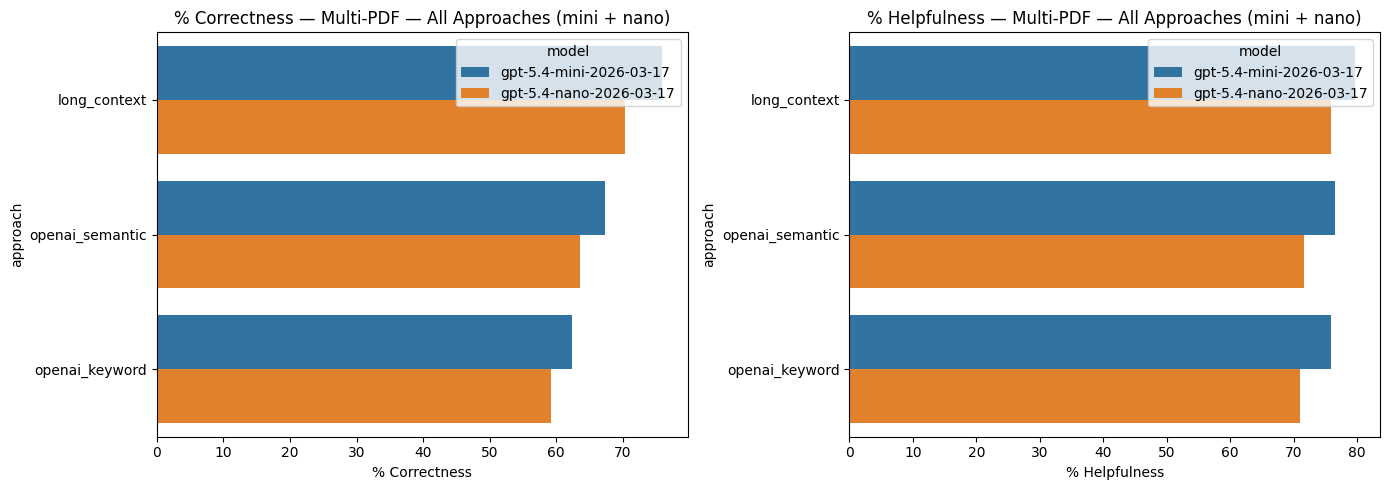

In [49]:
df = load(MERGED_OUTPUT)
print(f"Rows: {len(df)}, Approaches: {sorted(df['approach'].unique())}, Models: {sorted(df['model'].unique())}")

agg = rank_table(df, ["approach", "model"])
display(agg[["approach","model","avg_latency","avg_price","pct_correct","pct_helpful","avg_score"]])
bar_charts(agg, title_suffix="Multi-PDF — All Approaches (mini + nano)")

## Approach Ranking (collapsed across models)

,approach,avg_latency,avg_price,pct_correct,pct_helpful,avg_score
0,long_context,4.690525,0.297482,73.148148,77.777778,75.462963
1,openai_semantic,5.398704,0.010276,65.432099,74.074074,69.753086
2,openai_keyword,5.085833,0.010505,60.802469,73.456790,67.129630


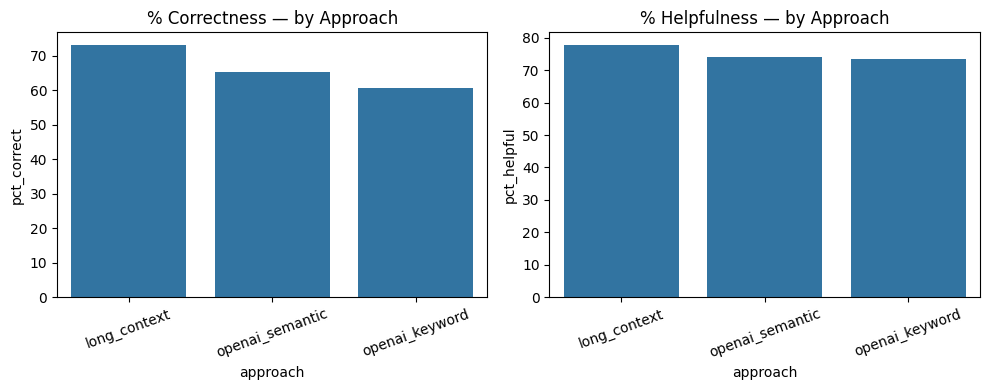

In [50]:
agg_approach = rank_table(df, ["approach"])
display(agg_approach[["approach","avg_latency","avg_price","pct_correct","pct_helpful","avg_score"]])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, label in zip(axes, ["pct_correct","pct_helpful"], ["% Correctness","% Helpfulness"]):
    sns.barplot(data=agg_approach, x="approach", y=col, ax=ax)
    ax.set_title(f"{label} — by Approach")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## Question-Level Breakdown

In [51]:
q_agg = (
    df.groupby("question")
    .agg(
        n=("judge_answer_correctness_vs_ref", "count"),
        pct_correct=("judge_answer_correctness_vs_ref", lambda x: x.mean() * 100),
        pct_helpful=("judge_answer_helpfulness", lambda x: x.mean() * 100),
    )
    .sort_values("pct_correct", ascending=False)
    .reset_index()
)
display(q_agg)

,question,n,pct_correct,pct_helpful
0,A client wants us to measure all out movements...,6,100.0,100.000000
1,Are there any safety instructions preventing m...,6,100.0,100.000000
2,Are there any safety warnings associated with ...,6,100.0,100.000000
3,Are there risks associated with using 12V vs 24V?,6,100.0,100.000000
4,Can I connect or disconnect my teach pendant w...,6,100.0,100.000000
...,...,...,...,...
157,What are the tool attachments I can put on the...,6,0.0,0.000000
158,What are the steps for moving the robot arm sa...,6,0.0,16.666667
159,What are the steps for the pre-operational saf...,6,0.0,50.000000
160,What is the procedure to change the drawbar on...,6,0.0,16.666667


## Heatmap: Question x Approach

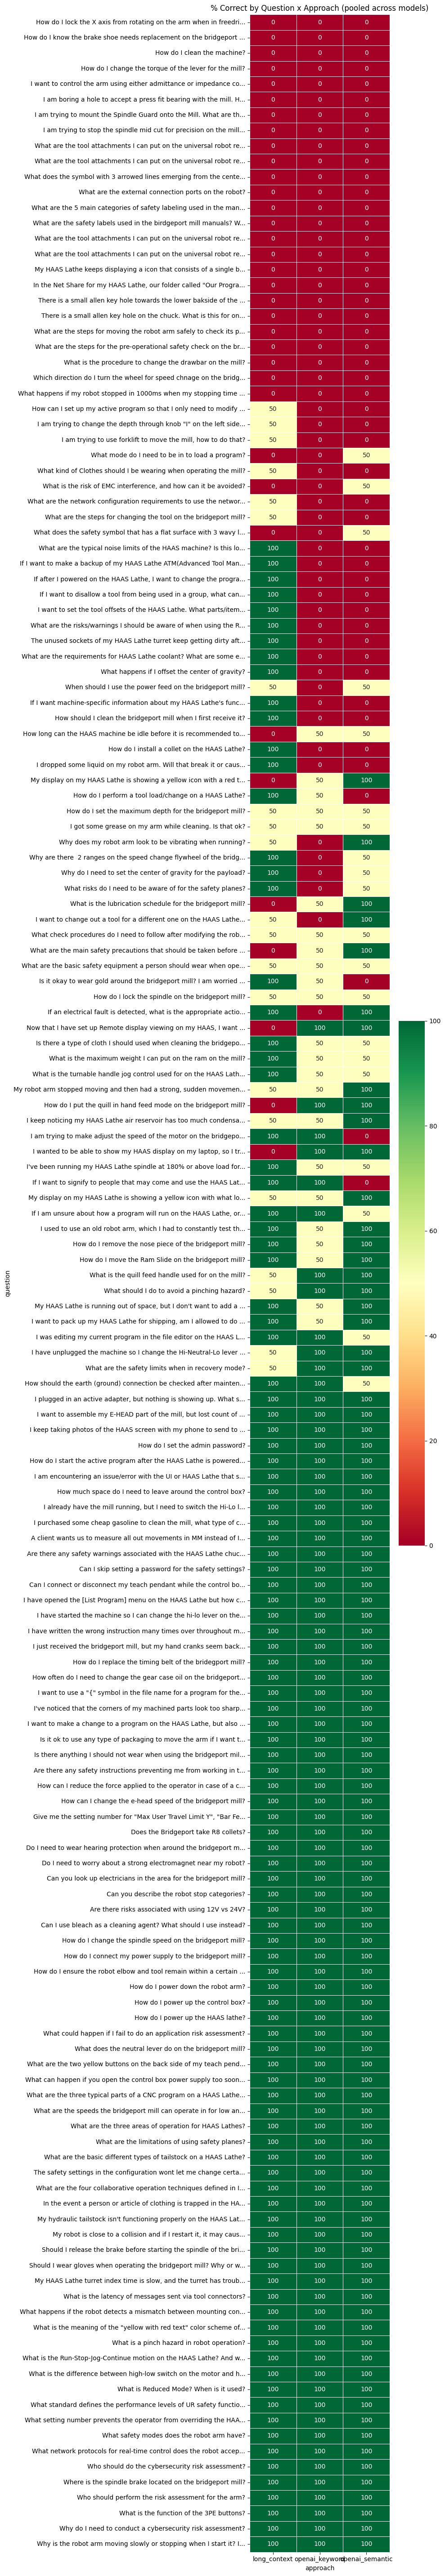

In [52]:
piv = (
    df.groupby(["question", "approach"])
    ["judge_answer_correctness_vs_ref"].mean()
    .unstack("approach") * 100
)
piv.index = piv.index.map(short_q)
piv = piv.loc[piv.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, max(18, len(piv) * 0.35)))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100, linewidths=0.5, ax=ax)
ax.set_title("% Correct by Question x Approach (pooled across models)")
plt.tight_layout(); plt.show()

## Per-Machine Breakdown

Does the LLM handle some manuals better than others when all 3 are in context?

,machine,approach,model,pct_correct,pct_helpful,avg_score
0,Lathe (HAAS TL-1),long_context,gpt-5.4-nano-2026-03-17,82.352941,84.313725,83.333333
1,Lathe (HAAS TL-1),long_context,gpt-5.4-mini-2026-03-17,82.352941,82.352941,82.352941
2,UR5e Cobot,long_context,gpt-5.4-mini-2026-03-17,78.333333,83.333333,80.833333
3,UR5e Cobot,openai_semantic,gpt-5.4-mini-2026-03-17,75.000000,85.000000,80.000000
4,UR5e Cobot,openai_keyword,gpt-5.4-nano-2026-03-17,66.666667,83.333333,75.000000
5,UR5e Cobot,openai_keyword,gpt-5.4-mini-2026-03-17,65.000000,85.000000,75.000000
6,UR5e Cobot,openai_semantic,gpt-5.4-nano-2026-03-17,70.000000,78.333333,74.166667
7,UR5e Cobot,long_context,gpt-5.4-nano-2026-03-17,68.333333,76.666667,72.500000
8,Lathe (HAAS TL-1),openai_semantic,gpt-5.4-mini-2026-03-17,66.666667,74.509804,70.588235
9,Mill (Bridgeport),long_context,gpt-5.4-mini-2026-03-17,66.666667,72.549020,69.607843


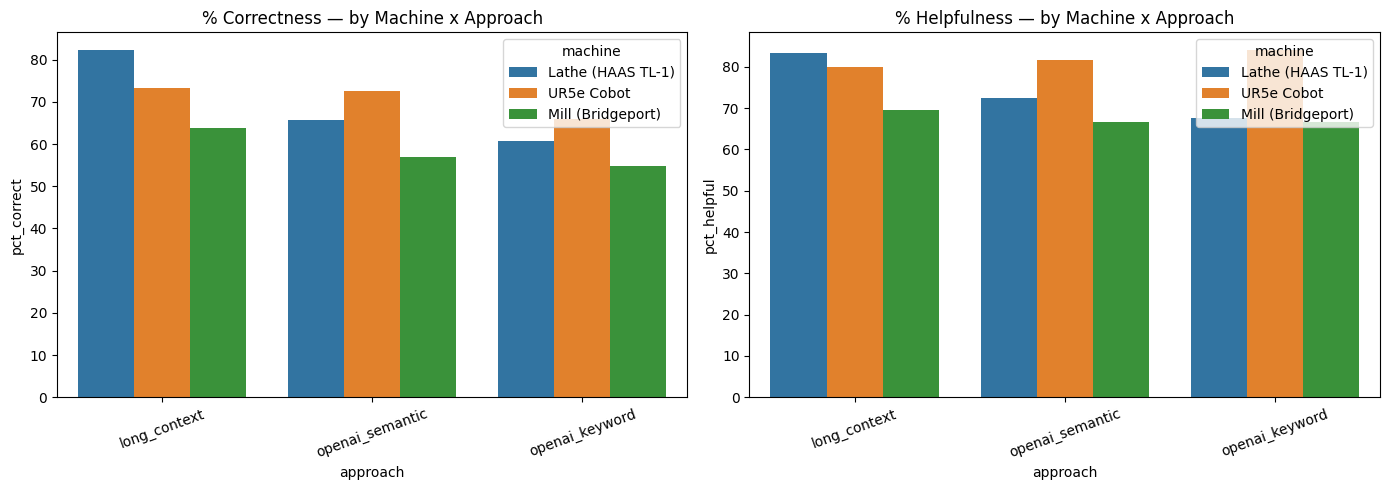

In [53]:
# Map questions back to their machine via the combined QA CSV
qa_map = pd.read_csv(COMBINED_QA).set_index("question")["machine"]
df["machine"] = df["question"].map(qa_map)

agg_machine = rank_table(df, ["machine", "approach", "model"])
display(agg_machine[["machine","approach","model","pct_correct","pct_helpful","avg_score"]])

# Bar chart: machine x approach
agg_m = rank_table(df, ["machine", "approach"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, label in zip(axes, ["pct_correct","pct_helpful"], ["% Correctness","% Helpfulness"]):
    sns.barplot(data=agg_m, x="approach", y=col, hue="machine", ax=ax)
    ax.set_title(f"{label} — by Machine x Approach")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## Difficulty Tier Analysis

In [54]:
q_overall = df.groupby("question")["judge_answer_correctness_vs_ref"].mean() * 100
q_tiers = pd.cut(q_overall, bins=[-1, 0, 50, 99, 100],
                 labels=["0% (never correct)", "1-50%", "51-99%", "100% (always correct)"])
q_tiers.name = "tier"

tier_counts = q_tiers.value_counts().sort_index()
print("Questions per difficulty tier:")
display(tier_counts.to_frame("n_questions"))

# Per-approach performance within each tier
df_tiered = df.merge(q_tiers.reset_index(), on="question")
for tier_name in tier_counts.index:
    subset = df_tiered[df_tiered["tier"] == tier_name]
    if len(subset) == 0:
        continue
    print(f"\n--- {tier_name} ({tier_counts[tier_name]} questions) ---")
    agg_t = rank_table(subset, ["approach"])
    display(agg_t[["approach","pct_correct","pct_helpful","avg_score"]])

Questions per difficulty tier:


,n_questions
tier,
0% (never correct),23
1-50%,39
51-99%,25
100% (always correct),75



--- 0% (never correct) (23 questions) ---


,approach,pct_correct,pct_helpful,avg_score
0,openai_keyword,0.0,26.086957,13.043478
1,openai_semantic,0.0,23.913043,11.956522
2,long_context,0.0,21.739130,10.869565



--- 1-50% (39 questions) ---


,approach,pct_correct,pct_helpful,avg_score
0,long_context,64.102564,78.205128,71.153846
1,openai_semantic,29.487179,53.846154,41.666667
2,openai_keyword,14.102564,52.564103,33.333333



--- 51-99% (25 questions) ---


,approach,pct_correct,pct_helpful,avg_score
0,openai_semantic,78.0,82.0,80.0
1,long_context,74.0,80.0,77.0
2,openai_keyword,72.0,76.0,74.0



--- 100% (always correct) (75 questions) ---


,approach,pct_correct,pct_helpful,avg_score
0,openai_keyword,100.0,98.000000,99.000000
1,openai_semantic,100.0,97.333333,98.666667
2,long_context,100.0,94.000000,97.000000


## Universally Missed Questions

Questions with 0% correctness across all approaches and models.

In [55]:
zero_qs = q_overall[q_overall == 0].index.tolist()
print(f"{len(zero_qs)} questions scored 0% across ALL approaches and models:\n")

for i, q in enumerate(zero_qs, 1):
    print(f"{'='*80}")
    print(f"Q{i}: {q}\n")

    gold = df.loc[df["question"] == q, "gold_answer"].iloc[0]
    print(f"GOLD ANSWER:\n{gold}\n")

    sample = df.loc[df["question"] == q].iloc[0]
    print(f"SAMPLE ({sample['approach']}, {sample['model']}):")
    print(f"{str(sample['generated_answer'])[:500]}\n")

23 questions scored 0% across ALL approaches and models:

Q1: How do I change the torque of the lever for the mill?

GOLD ANSWER:
You can change this using hi-lo mechanical lever. 

The Hi-Neutral-Lo Lever “O”, Figure 2.13, is used to put the attachment into either back gear or
direct drive. Rotate the spindle by hand to facilitate meshing of clutch or gears.

SAMPLE (openai_keyword, gpt-5.4-mini-2026-03-17):
The provided documents do not explain how to change the torque of the lever for the mill. They only list parts for the power feed assemblies, including standard torque and high torque motor options. [009__L1__Chapter_4_-_Parts_Listings__pp63-114__L2__14__6F_Power_Feed_X-Axis__pp97-99.pdf] [009__L1__Chapter_4_-_Parts_Listings__pp63-114__L2__15__8F_Power_Feed_X-Axis__pp100-103.pdf]

Q2: How do I clean the machine?

GOLD ANSWER:
Prepare the surface by removing loose dirt or debris. Apply a cleaning agent to the surface that needs cleaning, agitater the agent for stubborn spots, let t

## UR5e Cobot Bottom 20 Failure Diagnostics


In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)

# Use the existing UR5e slice from the analysis above. If this notebook is
# re-run from an older checkpoint that lacks it, recreate the same slice.
if "cobot_df" not in globals():
    if "machine" not in df.columns:
        df["machine"] = df["question"].map(qa_map)
    cobot_df = df[df["machine"] == "UR5e Cobot"].copy()

cobot_incorrect = cobot_df[cobot_df["judge_answer_correctness_vs_ref"] == False].tail(20).copy()

base_inspection_cols = [
    "question",
    "gold_answer",
    "generated_answer",
    "approach",
    "model",
    "cosine",
    "rougeL",
    "bleu",
]
source_keywords = ("retrieved", "source", "page", "chunk", "file", "context")
source_cols = [
    c for c in cobot_incorrect.columns
    if any(k in c.lower() for k in source_keywords) and c not in base_inspection_cols
]

print(f"UR5e Cobot incorrect rows: {len(cobot_df[cobot_df['judge_answer_correctness_vs_ref'] == False])}")
print(f"Bottom 20 rows selected: {len(cobot_incorrect)}")
if source_cols:
    print(f"Retrieved/source/context columns: {source_cols}")
else:
    print("WARNING: no retrieved/source/page/chunk/context columns found.")

def inspect_cobot_failure(position):
    """Display one row from the bottom-20 incorrect UR5e Cobot slice."""
    row = cobot_incorrect.iloc[position - 1]
    print(f"Bottom-20 position: {position}")
    print(f"DataFrame index: {row.name}")
    available_cols = [c for c in base_inspection_cols if c in cobot_incorrect.columns]
    if source_cols:
        available_cols += source_cols
    else:
        print("WARNING: no retrieved/source/page/chunk/context columns found.")
    display(row[available_cols].to_frame("value"))


In [ ]:
inspect_cobot_failure(1)


### Failure 1

**Classification:** source ambiguity; generation failure

The answer blended HAAS and UR5e program-loading behavior and concluded there was no single required mode. The gold answer expects the UR distinction: Automatic Mode to load/execute, Manual Mode to modify/create programs.


In [ ]:
inspect_cobot_failure(2)


### Failure 2

**Classification:** retrieval failure; source ambiguity; generation failure

The answer used HAAS VPS/macros instead of the UR5e active-program variable workflow. It missed the expected point that program variables can be favorited so only the frequently changed variables are easy to access.


In [ ]:
inspect_cobot_failure(3)


### Failure 3

**Classification:** generation failure

The answer found UR5e cleaning-agent guidance, but it did not reproduce the procedure in the gold answer: remove loose debris, apply and agitate cleaner, wait five minutes, rinse with water, then air dry or towel dry.


In [ ]:
inspect_cobot_failure(4)


### Failure 4

**Classification:** generation failure; naming mismatch

The answer understood that Freedrive has axis-lock controls, but it stayed generic and did not map rotational X to the specific `RX` toggle. The failure is mostly a missed UI-name/detail issue.


In [ ]:
inspect_cobot_failure(5)


### Failure 5

**Classification:** retrieval failure; source ambiguity

The answer treated high-rate admittance/impedance control as unsupported by the provided context. The gold answer depends on lower-level control details, direct torque/control API limitations, and a 125 Hz UR update-rate detail that were not surfaced in the response.


In [ ]:
inspect_cobot_failure(6)


### Failure 6

**Classification:** generation failure

The answer recognized grease as an irritant/allergen, but it avoided the direct safety answer. The gold answer expects: no, it is not okay; wash the affected area with water and mild cleaning agent.


In [ ]:
inspect_cobot_failure(7)


### Failure 7

**Classification:** retrieval failure; source ambiguity

The answer diagnosed the stop-and-sudden-motion symptom as a safety-stop/recovery-mode issue. The gold answer attributes it to a singularity and expects prevention guidance around avoiding poses that create singularities.


In [ ]:
inspect_cobot_failure(8)


### Failure 8

**Classification:** retrieval failure; source ambiguity

The answer cited normal startup vibration and said running vibration was not determined. The gold answer expects the stand-resonance explanation: if the stand resonance frequency is below 45 Hz, robot motion can make the system appear to vibrate.


In [ ]:
inspect_cobot_failure(9)


### Failure 9

**Classification:** generation failure

The answer covered disconnecting power and related maintenance precautions, but missed several required gold-answer items: discharge the control box, observe ESD rules, and prevent dust or water ingress.


In [ ]:
inspect_cobot_failure(10)


### Failure 10

**Classification:** generation failure; grading issue

The answer matches most of the network-configuration gold answer: trusted network/devices, no inbound adjacent-network access, and restricted outbound ports/protocols/addresses. It was likely marked incorrect because it omitted the URCaps and magic-script authenticity/integrity requirement, so this is a borderline grading/completeness case.


In [ ]:
inspect_cobot_failure(11)


### Failure 11

**Classification:** retrieval failure; generation failure

The answer only mentioned capped openings and Mini DisplayPort. It missed the expected external-port list: Teach Pendant port, SD card slot, Ethernet, USB 2.0/3.0, Mini DisplayPort, and 10A mini blade fuse.


In [ ]:
inspect_cobot_failure(12)


### Failure 12

**Classification:** generation failure; grading issue

The answer included the main stability-test flow, including zero position, disconnecting power, Freedrive, and checking that the arm holds position. It missed the explicit cable-and-bolt inspection from the gold answer, so this is mostly an incomplete-answer failure and may be close enough depending on grading strictness.


In [ ]:
inspect_cobot_failure(13)


### Failure 13

**Classification:** grading issue

The generated answer gives the same default recovery-mode limits as the gold answer: joint speed 30 deg/s, speed 250 mm/s, force 100 N, momentum 10 kg m/s, and power 80 W. The only missing nuance is that changed safety settings can affect the listed limits, so this looks like a likely false negative or overly strict grading.


In [ ]:
inspect_cobot_failure(14)


### Failure 14

**Classification:** retrieval failure; source ambiguity

The answer stayed at the generic end-effector/tool-flange level and did not list object-moving attachment types. The gold answer expects gripper categories such as parallel, three-finger, vacuum, magnetic, soft, and precision grippers.


In [ ]:
inspect_cobot_failure(15)


### Failure 15

**Classification:** source ambiguity; naming mismatch; grading issue

The answer says the manual mentions welding as a tool purpose but does not list specific welding attachments. The gold answer is very short and expects welding/arc-welding attachments, so this failure may come from a mismatch between the expected answer and what the available source text explicitly supports.


In [ ]:
inspect_cobot_failure(16)


### Failure 16

**Classification:** chunking/PDF parsing issue; retrieval failure

The question depends on a visual icon legend. The generated answer could not identify the symbol, which suggests the relevant figure/icon label was not available in text retrieval or was lost during PDF parsing. The gold answer is the Translation control mode icon.


In [ ]:
inspect_cobot_failure(17)


### Failure 17

**Classification:** generation failure; source ambiguity

The answer described stopping-time monitoring, speed reduction, and Stop Category 0, but missed the expected consequence that violating the stopping-time safety limit puts the robot arm into recovery mode.


In [ ]:
inspect_cobot_failure(18)


### Failure 18

**Classification:** generation failure; retrieval failure

The answer identified EMC risk from high signal levels and welding environments, but missed the mitigation details in the gold answer: avoid long cables and maintain grounding.


In [ ]:
inspect_cobot_failure(19)


### Failure 19

**Classification:** source ambiguity; retrieval failure

This is the same mode question as row 1, but the nano long-context answer anchored on HAAS lathe controls instead of UR5e program modes. The failure is cross-document contamination in the multi-PDF context.


In [ ]:
inspect_cobot_failure(20)


### Failure 20

**Classification:** generation failure

The answer gave general pinch-safety advice, but missed the specific controls in the gold answer: remove obstacles around the robot, use stricter safety planes and joint limits, and check recommended special needs for the robot arm.
